In [49]:
import tifffile as tf
import os
import numpy as np
from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import contextily as cx
pd.options.mode.chained_assignment = None

In [50]:
data_folder = os.environ["DATA_FOLDER"]
label_path = f"{data_folder}/local/label/"
aois = gpd.read_file(f"{data_folder}/metadata/aoi_extent.geojson")
all_label_paths = [label_path+path for path in os.listdir(label_path)]
raster_extents = gpd.read_file(f"{data_folder}/metadata/raster_extent.geojson")
events = pd.read_csv(f"{data_folder}/metadata/events.csv")
data = pd.read_csv(f"{data_folder}/metadata/dataset_distributions.csv")
desc = pd.read_csv(f"{data_folder}/metadata/subevent_descriptions.csv")

missing_features = ["sentinel1"]
features = [(feature_name, band_index) for feature_name, feature_count in zip(["dem", "permanent_water", "soil_bulk_density", "soil_class", "label", 
                                                                                   "soil_moisture_one_day", "soil_moisture_one_week", "sentinel2", "sentinel1"],
                                                                                  [1, 1, 1, 1, 1, 2, 2, 12, 3]) for band_index in range(feature_count)]
features = features + [("precipitation", (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13)), ("precipitation", 14), ("precipitation", 15)]
band_names = {"sentinel2": {0:"B02", 1:"B03", 2:"B04", 3:"B05", 4:"B06", 5:"B07", 6:"B08", 7:"B8A", 8:"B11", 9:"B12", 10:"CLD", 11:"date_difference"}, 
              "sentinel1": {0:"VV", 1:"VH", 2:"date_difference"}, "soil_class": {0: "class"}, "label": {0:"class"}, "dem": {0:"elevation"}, 
              "soil_bulk_density": {0: "density"}, "soil_moisture_one_day": {0: "surface", 1: "root"}, "soil_moisture_one_week": {0: "surface", 1: "root"},
              "permanent_water": {0:"water"}, "precipitation": {(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13):"days 1-14", 14:"days 15-28", 15:"days 29-42"}}

In [51]:
def find_bins(df, feature, band, num_bins):
    value_counts = df[df["feature"]==f"{feature}_{band}"]
    value_counts = value_counts.set_index("value").to_dict()["count"]
    minimum, maximum = min(value_counts.keys()), max(value_counts.keys())+1
    bins = np.linspace(minimum, maximum, num_bins+1)
    binned_counts = np.zeros(num_bins, dtype=int)
    for value, count in value_counts.items():
        bin_index = np.searchsorted(bins, value, side='right') - 1
        if 0 <= bin_index < num_bins:
            binned_counts[bin_index] += count
    return binned_counts, bins

def find_min_max_mean(df, feature, band):
    value_counts = df[df["feature"]==f"{feature}_{band}"]
    mean = (value_counts["value"] * value_counts["count"]).sum() / value_counts["count"].sum()
    return value_counts["value"].min(), value_counts["value"].max(), mean

def plot_features(df, features, band_names):
    num_features = len(features)
    fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(12, 3*num_features))

    for index, (feature, band) in enumerate(features):
            binned_counts, bins = find_bins(df, feature, band, num_bins=100)
            minimum, maximum, mean = find_min_max_mean(df, feature, band)
            band_name = band_names[feature][band]

            for col_ax in [0, 1]:
                    axes[index, col_ax].bar(bins[:-1], binned_counts, width=np.diff(bins), align="edge", edgecolor="white", color="darkturquoise", zorder=100)
                    axes[index, col_ax].grid(alpha=0.3, axis="y", zorder=-100)
                    axes[index, col_ax].set_xlabel(f"Value of feature")

            axes[index, 0].set_ylabel("Count")
            axes[index, 0].set_title(f"Distribution of '{feature}', band '{band_name}'")
            axes[index, 0].text(0.8, 0.7, f"Min: {minimum:.0f}\nMax: {maximum:.0f}\nMean: {mean:.0f}", transform=axes[index, 0].transAxes,
                            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.5"))
            axes[index, 0].axvline(x=mean, color="red", zorder=500)
            
            axes[index, 1].set_title(f"Distribution of '{feature}', band '{band_name}' (log scale)")
            axes[index, 1].set_ylabel("Count (log scale)")
            axes[index, 1].set_yscale("log")

    fig.tight_layout()

def plot_feature(df, feature, band, shift=0, log=False):
    feature_data = df[df["feature"]==f"{feature}_{band}"]
    feature_data["value"] = feature_data["value"]+shift
    if log:
         feature_data["value"] = np.log(feature_data["value"])
    binned_counts, bins = find_bins(feature_data, feature, band, num_bins=100)
    minimum, maximum, mean = find_min_max_mean(feature_data, feature, band)
    band_name = band_names[feature][band]
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 3))
    for col_ax in [0, 1]:
            axes[col_ax].bar(bins[:-1], binned_counts, width=np.diff(bins), align="edge", edgecolor="white", color="darkturquoise", zorder=100)
            axes[col_ax].grid(alpha=0.3, axis="y", zorder=-100)
            axes[col_ax].set_xlabel(f"Value of feature")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of '{feature}', band '{band_name}'. Log:{log}, Shift:{shift}.")
    axes[0].text(0.8, 0.7, f"Min: {minimum:.0f}\nMax: {maximum:.0f}\nMean: {mean:.0f}", transform=axes[0].transAxes,
                    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.5"))
    axes[0].axvline(x=mean, color="red", zorder=500)
    axes[1].set_title(f"Distribution of '{feature}', band '{band_name}' (log scale)")
    axes[1].set_ylabel("Count (log scale)")
    axes[1].set_yscale("log")

## Flood Events

In [52]:
print(f"Number of flood events: {raster_extents.event.nunique()}")
print(f"Number of flood subevents (flood events across different days): {raster_extents.subevent.nunique()}")

Number of flood events: 170
Number of flood subevents (flood events across different days): 667


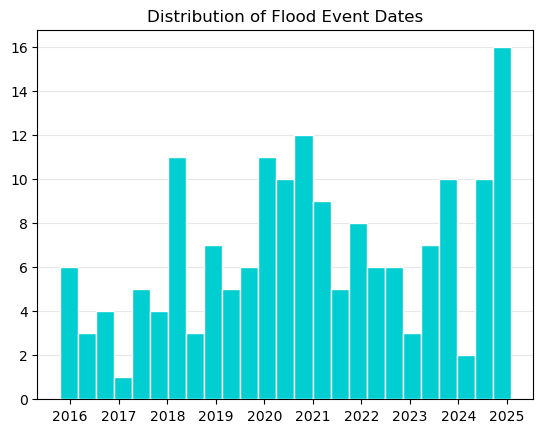

In [6]:
ax = raster_extents.sort_values("date").drop_duplicates("event", keep="first").hist("date", bins=25, edgecolor="white", color="darkturquoise", grid=False, zorder=100).flatten()[0]
ax.set_title("Distribution of Flood Event Dates");
ax.grid(alpha=0.3, axis="y", zorder=-100)

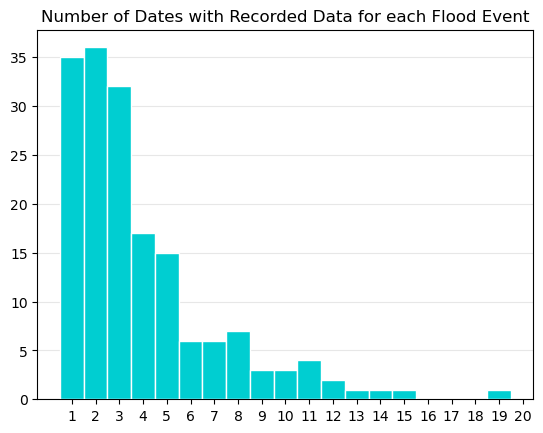

In [7]:
ax = raster_extents.groupby("event").count().hist("subevent", bins=np.arange(1, 21, 1), edgecolor="white", color="darkturquoise", grid=False, zorder=100, align="left").flatten()[0]
ax.set_title("Number of Dates with Recorded Data for each Flood Event");
ax.set_xticks(np.arange(1, 21, 1))
ax.grid(alpha=0.3, axis="y", zorder=-100)

In [25]:
desc.drop_duplicates("event")["flood_cause"].value_counts()

flood_cause
fluvial_pluvial    151
snow_melt           13
dam_overflow         4
storm_surge          2
Name: count, dtype: int64

In [53]:
print(f"Flood events in {desc.drop_duplicates("event")["country"].nunique()} different countries and {desc.drop_duplicates("event")["continent"].nunique()} continents. \n")

print("Top countries:")
display(desc.drop_duplicates("event")["country"].value_counts().head(10))

print("Top continents:")
display(desc.drop_duplicates("event")["continent"].value_counts().head(10))

Flood events in 52 different countries and 6 continents. 

Top countries:


country
Italy             19
Germany           13
France            13
Australia         11
Spain              8
Greece             8
United Kingdom     7
Ireland            5
Viet Nam           5
Norway             5
Name: count, dtype: int64

Top continents:


continent
Europe           113
Africa            23
Asia              15
Oceania           11
North America      5
South America      3
Name: count, dtype: int64

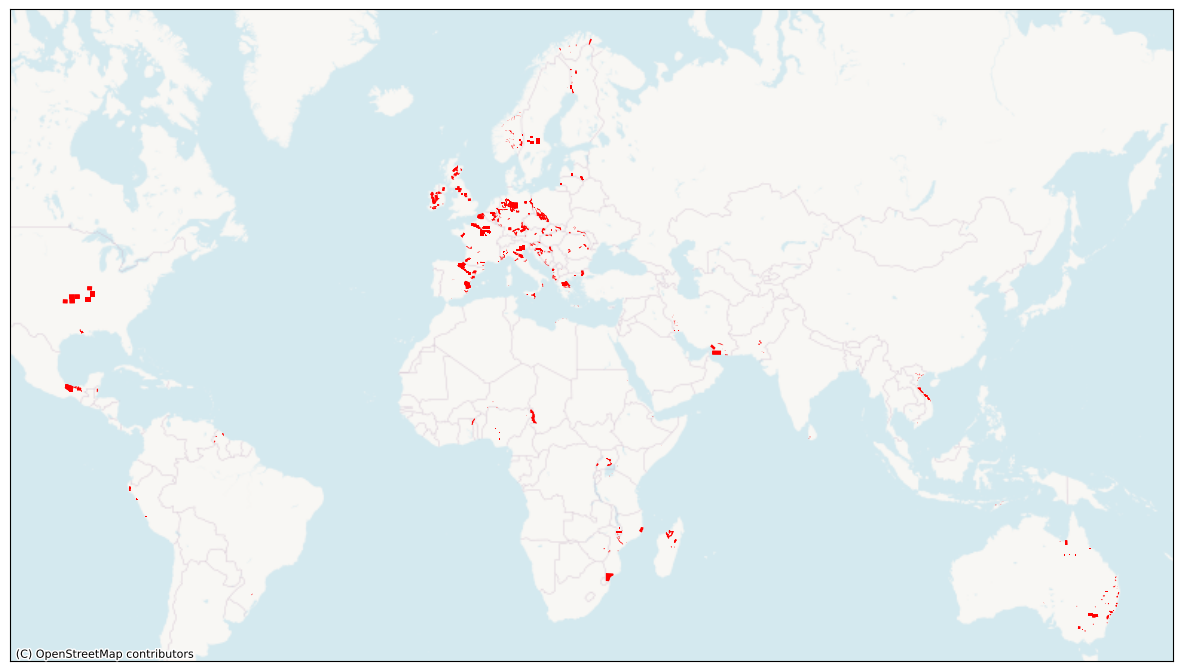

In [16]:
ax = aois.to_crs("EPSG:3857").plot(figsize=(15, 15), color="red")
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)
ax.set_xticks([]), ax.set_yticks([]);

## Flood Dataset Patches

In [21]:
print(f"Number of patches: {len(all_label_paths):,}")

Number of patches: 295,920


In [44]:
contains_flood_water = 0
for path in tqdm(all_label_paths, leave=False):
    if np.isin(tf.imread(path), [2, 3]).any():
        contains_flood_water += 1

print(f"Percentage of patches containing flood water labels: {(contains_flood_water/len(all_label_paths))*100:.2f}%")

Percentage of patches containing flood water labels: 30.81%


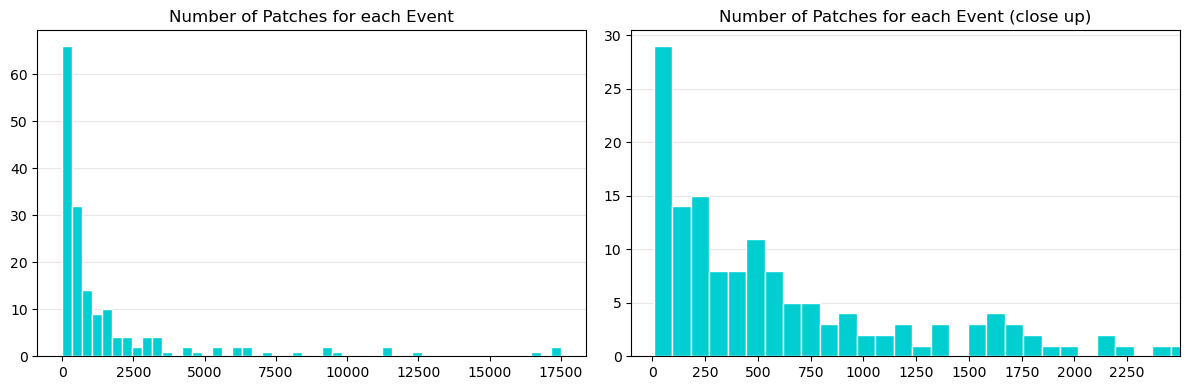

In [13]:
patch_dist_over_event = pd.Series([path.split("/")[-1].split("_")[0] for path in all_label_paths]).value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
for index, bins in zip(range(2), [50, 200]):
    patch_dist_over_event.hist(bins=bins, edgecolor="white", color="darkturquoise", grid=False, zorder=100, ax=axes[index])
    axes[index].grid(alpha=0.3, axis="y", zorder=-100)
    axes[index].set_title("Number of Patches for each Event");
axes[1].set_xlim(-100, 2500)
axes[1].set_xticks(np.arange(0, 2500, 250))
axes[1].set_title("Number of Patches for each Event (close up)")
fig.tight_layout()

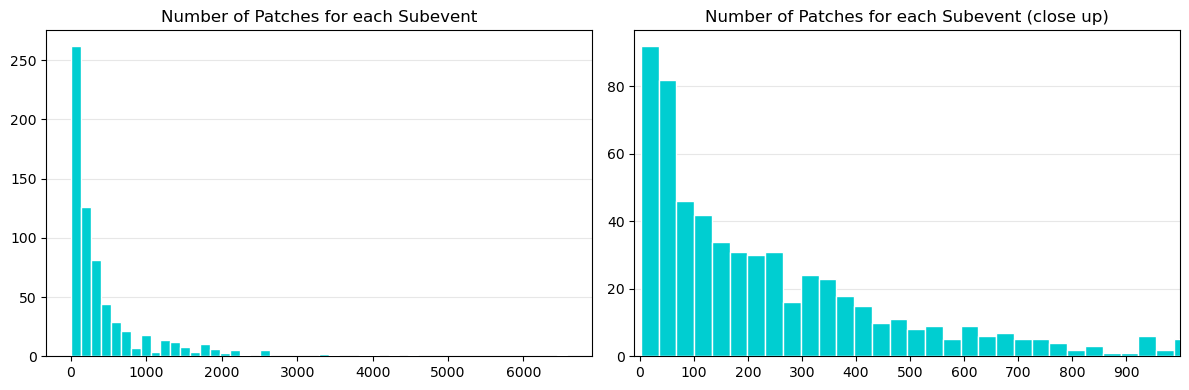

In [14]:
patch_dist_over_subevent = pd.Series(["_".join(path.split("/")[-1].split("_")[0:2]) for path in all_label_paths]).value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
for index, bins in zip(range(2), [50, 200]):
    patch_dist_over_subevent.hist(bins=bins, edgecolor="white", color="darkturquoise", grid=False, zorder=100, ax=axes[index])
    axes[index].grid(alpha=0.3, axis="y", zorder=-100)
    axes[index].set_title("Number of Patches for each Subevent");
axes[1].set_xlim(-10, 1000)
axes[1].set_xticks(np.arange(0, 1000, 100))
axes[1].set_title("Number of Patches for each Subevent (close up)")
fig.tight_layout()

## Feature Distributions

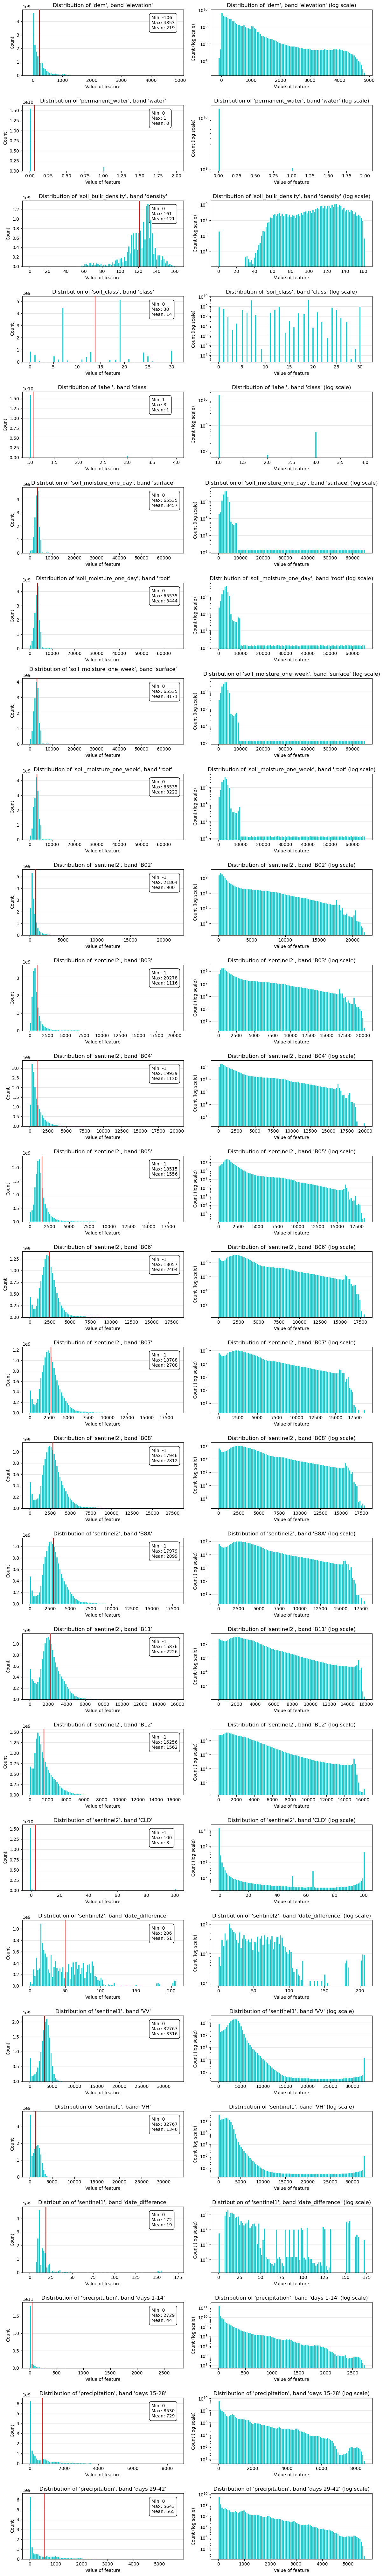

In [ ]:
plot_features(data, features, band_names)

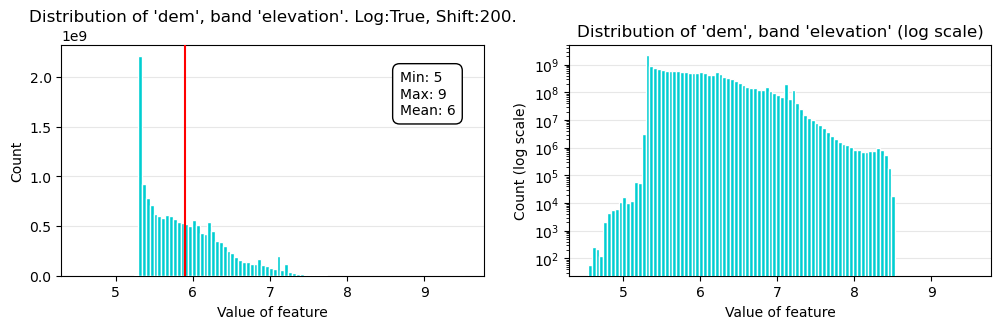

In [36]:
plot_feature(data, feature="dem", band=0, shift=200, log=True)

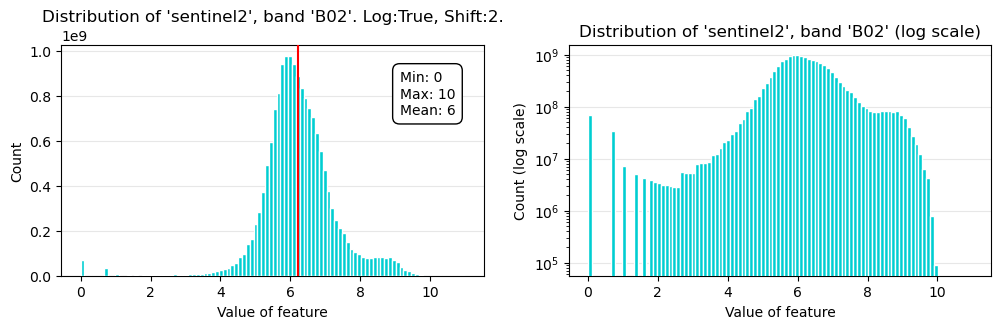

In [37]:
plot_feature(data, "sentinel2", 0, shift=2, log=True)

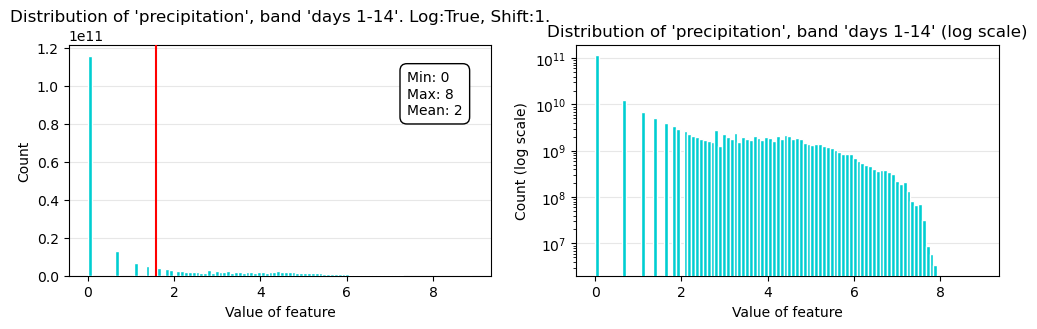

In [39]:
plot_feature(data, "precipitation", (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13), shift=1, log=True)

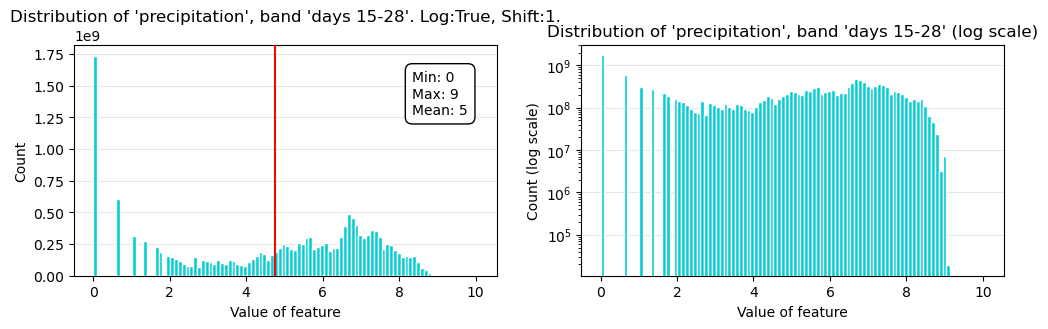

In [40]:
plot_feature(data, "precipitation", 14, shift=1, log=True)

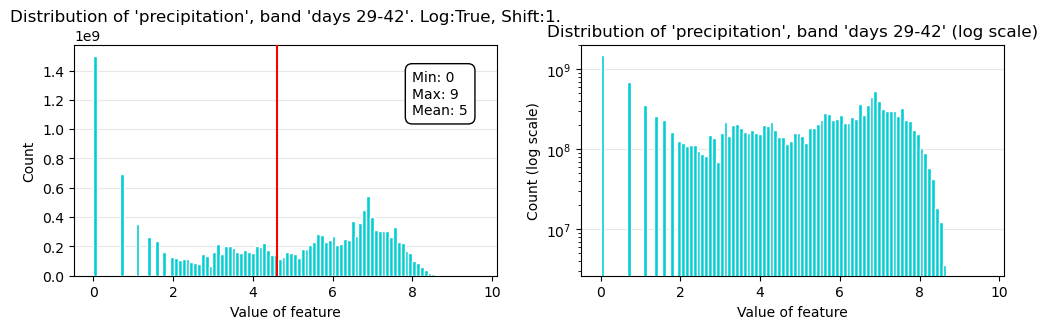

In [41]:
plot_feature(data, "precipitation", 15, shift=1, log=True)